In [1]:
import numpy as np
from matplotlib import pyplot as plt
from RVSS_EOS_Slope import RVSS_EOS_Slope as rvss_eos
import os
import kuibit.simdir as SD
import pickle
from scipy.interpolate import interp1d



This notebook explores correlations between sound speed related quantities for the alpha models and gravitational wave/simulation observables

In [3]:
Alpha_A = rvss_eos(1200,mu_max=2700)
Alpha_E = rvss_eos(1300,mu_max=2700)
Alpha_B = rvss_eos(1400,mu_max=2700)
Alpha_C = rvss_eos(1500,mu_max=2700)
Alpha_D = rvss_eos(1700,mu_max=2700)

RVSS_List = {'A': (Alpha_A,'red'),
             'B': (Alpha_B,'blue'),
             'C': (Alpha_C,'green'),
             'D': (Alpha_D,'black'),
             'E': (Alpha_E,'purple')}

matching pressure: 3.012
mu match: 974.394
cs2 match: 0.051


/home/john/PhD_Projects/High_Density_Sound_Speed/RVSS_EOS_Slope.py:104: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  integral_pr = press_compose[-1] + quad(lambda mu_p: nb_interp(mu_p),mu_m,mu,limit=200)


Done
alpha = 0.003985692037555738
matching pressure: 3.012
mu match: 974.394
cs2 match: 0.051
Done
alpha = 0.002761607731865443
matching pressure: 3.012
mu match: 974.394
cs2 match: 0.051
Done
alpha = 0.002112742893851452
matching pressure: 3.012
mu match: 974.394
cs2 match: 0.051
Done
alpha = 0.0017107796622185417
matching pressure: 3.012
mu match: 974.394
cs2 match: 0.051
Done
alpha = 0.0012392345966394309


In [49]:
Models = ["A","B","C","D","E"]
Masses = ["1p3M","1p35M","1p4M"]
Model_Dirs = {(m,mass):f"./RVSS_GW_Data/Model_{m}/{mass}" for m in Models for mass in Masses if os.path.isdir(f"./RVSS_GW_Data/Model_{m}/{mass}")}

Sim_Dirs = {key:SD.SimDir(path) for key,path in Model_Dirs.items()}
mvr_files = {model: os.path.abspath(f"./MVR/RVSS/{model}_MVR.txt") for model in Models if os.path.isfile(os.path.abspath(f"./MVR/RVSS/{model}_MVR.txt"))}
mvr_files_core = [os.listdir('./MVR/CORE/')]

In [ ]:
for file in mvr_files_core:

[['LS220_MVR.txt', 'DD2F_MVR.txt', 'BHBlp_MVR.txt', 'BLh_MVR.txt', 'DD2_MVR.txt', 'BLQ_MVR.txt', 'DD2F-SF1_MVR.txt', 'SFHo_MVR.txt', 'SLy4_MVR.txt', 'BA_MVR.txt']]


We start by importing the GW quantities for each run. ($h_{22}$, $E_{GW}$, $J_{GW}$, $L_{GW}$)

In [5]:
with open('./pickle_files/gw_data/RVSS_h22.pkl','rb') as h_22_pkl:
    rh_22_RVSS = pickle.load(h_22_pkl)
with open('./pickle_files/gw_data/RVSS_EGW_tot.pkl','rb') as e_gw_pkl:
    e_gw_rvss = pickle.load(e_gw_pkl)
with open('./pickle_files/gw_data/RVSS_JGW_tot.pkl','rb') as j_gw_pkl:
    j_gw_rvss = pickle.load(j_gw_pkl)
with open('./pickle_files/gw_data/RVSS_Lpk.pkl','rb') as L_pk_pkl:
    L_gw_rvss = pickle.load(L_pk_pkl)
with open('./pickle_files/gw_data/MF2_RVSS.pkl','rb') as MF2_pkl:
    MF2_RVSS = pickle.load(MF2_pkl)


In [30]:
with open('./pickle_files/ejecta/M_ej_tot_1p4.pkl','rb') as file:
    avg_ej_tot_1p4 = pickle.load(file)
with open('./pickle_files/ejecta/M_ej_tot_1p35.pkl','rb') as file:
    avg_ej_tot_1p35 = pickle.load(file)
with open('./pickle_files/ejecta/M_ej_tot_1p3.pkl','rb') as file:
    avg_ej_tot_1p3 = pickle.load(file) 

with open('./pickle_files/ejecta/M_ej_shk_1p4.pkl','rb') as file:
    avg_ej_shk_1p4 = pickle.load(file)
with open('./pickle_files/ejecta/M_ej_shk_1p35.pkl','rb') as file:
    avg_ej_shk_1p35 = pickle.load(file)
with open('./pickle_files/ejecta/M_ej_shk_1p3.pkl','rb') as file:
    avg_ej_shk_1p3 = pickle.load(file)

A
B
C
D
E


Text(0, 0.5, '$(c_s^2)_{c}$')

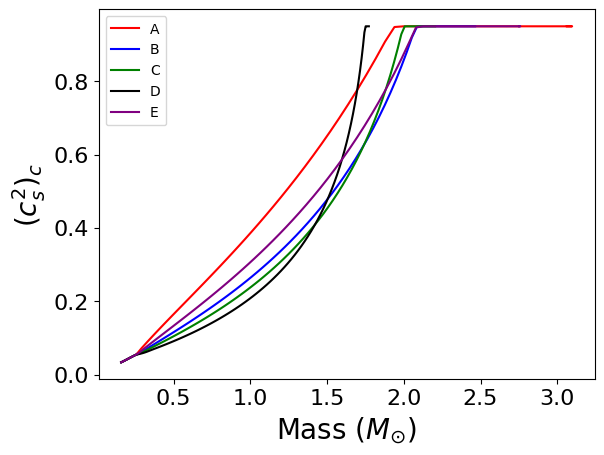

In [21]:


Mass = {}
Radius = {}
cs2_c = {}
cs2c_1p6 = {}
cs2c_1p8 = {}
Lambda = {}
k2 = {}
cs2_c_interp = {}

for model in Models:
    print(model)
    mvr_data = np.loadtxt(mvr_files[model],skiprows=1)
    Mass[model] = mvr_data[:,0]
    Radius[model] = mvr_data[:,1]
    cs2_c[model]  = mvr_data[:,3]
    Lambda[model] = mvr_data[:,5]
    k2[model] = mvr_data[:,6]
    cs2_c_interp[model] = interp1d(Mass[model],cs2_c[model])

    cs2c_1p6[model] = cs2_c_interp[model](1.6)
    #cs2c_1p8[model] = cs2_c_interp[model](1.8)
    plt.plot(Mass[model],cs2_c[model],color=RVSS_List[model][1],label=model,linewidth=1.5)
plt.legend()
plt.xlabel(r'$\text{Mass }(M_{\odot})$',fontsize=20)
plt.ylabel(r'$(c_s^2)_{c}$',fontsize=20)


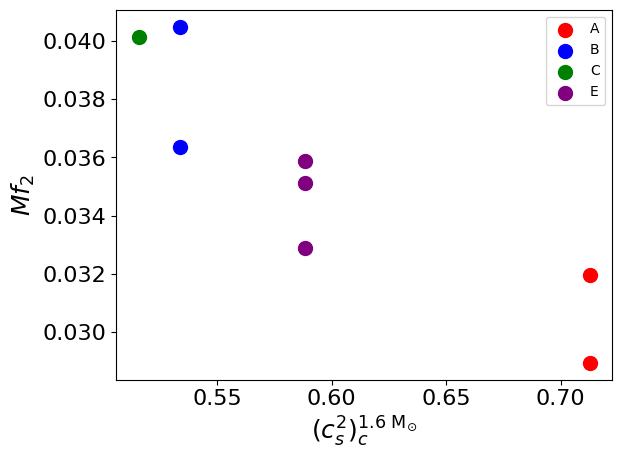

In [41]:
plotted = {'A': False,
           'B': False,
           'C': False,
           'D': False,
           'E': False,}
for (model,mass),mf2 in MF2_RVSS.items():
    mass = float(mass[0:-1].replace('p','.'))
    cs2_cent = cs2_c_interp[model](mass)
    if not plotted[model]:
        plt.scatter(cs2c_1p6[model],mf2,color=RVSS_List[model][1],label=model)
        plotted[model] = True
    else:
        plt.scatter(cs2c_1p6[model],mf2,color=RVSS_List[model][1])
plt.xlabel(r'$(c_s^2)^{1.6 \text{ M}_{\odot}}_{c}$',fontsize=18)
plt.ylabel(r'$Mf_2$',fontsize=18)
plt.legend()
plt.savefig('./Figures/Final_Paper_Figs/MF2_Plots/Mf2_1p6_cs2.pdf',format='pdf')

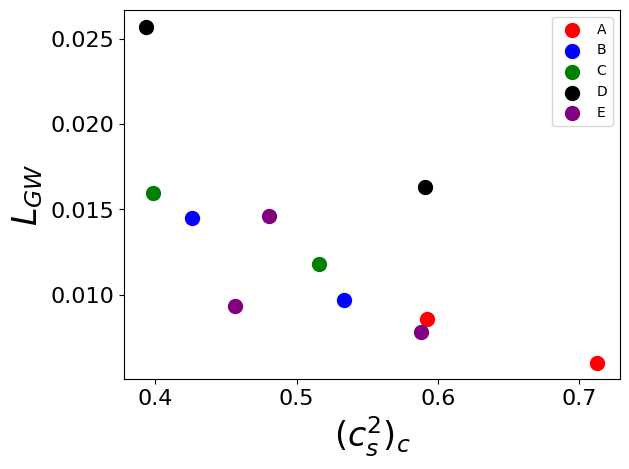

In [27]:
plotted = {'A': False,
           'B': False,
           'C': False,
           'D': False,
           'E': False,}
for (model,mass),l_gw in L_gw_rvss.items():
    mass = float(mass[0:-1].replace('p','.'))
    cs2_cent = cs2_c_interp[model](mass)
    if not plotted[model]:
        plt.scatter(cs2c_1p6[model],l_gw,color=RVSS_List[model][1],label=model)
        plotted[model] = True
    else:
        plt.scatter(cs2_cent,l_gw,color=RVSS_List[model][1])
plt.xlabel(r'$(c_s^2)_{c}$',fontsize=24)
plt.ylabel(r'$L_{GW}$',fontsize=24)
plt.legend()

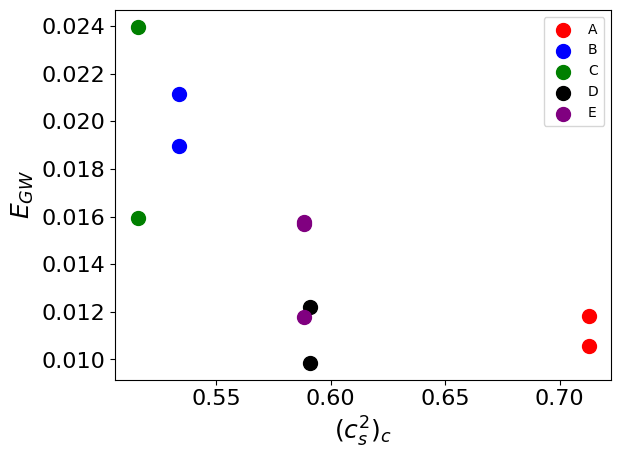

In [46]:
plotted = {'A': False,
           'B': False,
           'C': False,
           'D': False,
           'E': False,}
for (model,mass),e_gw in e_gw_rvss.items():
    mass = float(mass[0:-1].replace('p','.'))
    #mass = 1.0
    cs2_cent = cs2_c_interp[model](mass)
    if not plotted[model]:
        plt.scatter(cs2c_1p6[model],e_gw/(2*mass),color=RVSS_List[model][1],label=model)
        plotted[model] = True
    else:
        plt.scatter(cs2c_1p6[model],e_gw/(2*mass),color=RVSS_List[model][1])
plt.xlabel(r'$(c_s^2)_{c}$',fontsize=18)
plt.ylabel(r'$E_{GW}$',fontsize=18)
plt.legend()
plt.savefig('./Figures/Final_Paper_Figs/Energetics/E_gw_cs2_c_1p6.pdf',format='pdf')

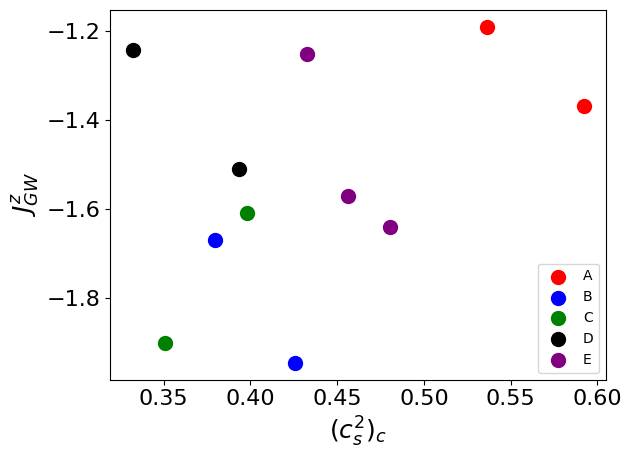

In [36]:
plotted = {'A': False,
           'B': False,
           'C': False,
           'D': False,
           'E': False,}
for (model,mass),j_gw in j_gw_rvss.items():
    mass = float(mass[0:-1].replace('p','.'))
    cs2_cent = cs2_c_interp[model](mass)
    if not plotted[model]:
        plt.scatter(cs2_cent,j_gw,color=RVSS_List[model][1],label=model)
        plotted[model] = True
    else:
        plt.scatter(cs2_cent,j_gw,color=RVSS_List[model][1])
plt.xlabel(r'$(c_s^2)_{c}$',fontsize=18)
plt.ylabel(r'$J^{z}_{GW}$',fontsize=18)
plt.legend()

{'A': 0.0013742276277442544, 'B': 0.0010884117965120036, 'C': 0.0008751608134839449, 'D': 1.9656104406539192e-06, 'E': 0.0010085039296448336}


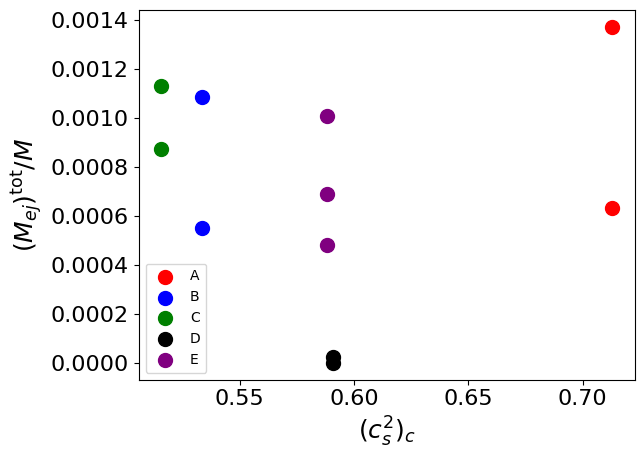

In [34]:
from matplotlib.font_manager import font_scalings


plotted = {'A': False,
           'B': False,
           'C': False,
           'D': False,
           'E': False,}
print(avg_ej_tot_1p4)
for model,tot_ej in avg_ej_tot_1p4.items():
    if not plotted[model]:
        plt.scatter(cs2c_1p6[model],tot_ej,color=RVSS_List[model][1],label=model)
        plotted[model] = True
    else:
        plt.scatter(cs2c_1p6[model],tot_ej,color=RVSS_List[model][1])


for model,tot_ej in avg_ej_tot_1p35.items():
    if not plotted[model]:
        plt.scatter(cs2c_1p6[model],tot_ej,color=RVSS_List[model][1],label=model)
        plotted[model] = True
    else:
        plt.scatter(cs2c_1p6[model],tot_ej,color=RVSS_List[model][1])



for model,tot_ej in avg_ej_tot_1p3.items():
    if not plotted[model]:
        plt.scatter(cs2c_1p6[model],tot_ej,color=RVSS_List[model][1],label=model)
        plotted[model] = True
    else:
        plt.scatter(cs2c_1p6[model],tot_ej,color=RVSS_List[model][1])
plt.xlabel(r'$(c_s^2)_c$',fontsize=18)
plt.ylabel(r'$(M_{ej})^{\text{tot}}/M$',fontsize=18)
plt.legend()



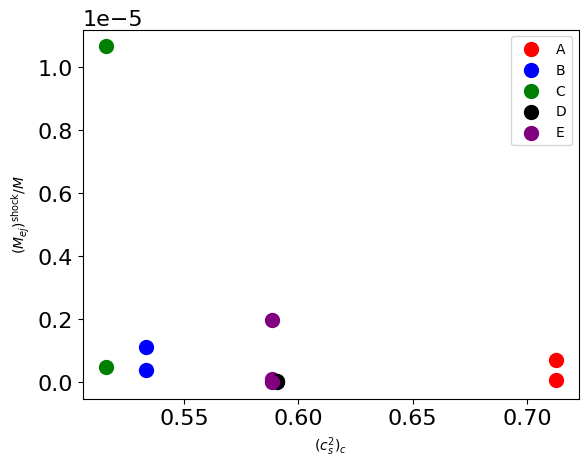

In [47]:
plotted = {'A': False,
           'B': False,
           'C': False,
           'D': False,
           'E': False,}

for model,shk_ej in avg_ej_shk_1p4.items():
    if not plotted[model]:
        plt.scatter(cs2c_1p6[model],shk_ej,color=RVSS_List[model][1],label=model)
        plotted[model] = True
    else:
        plt.scatter(cs2c_1p6[model],shk_ej,color=RVSS_List[model][1])


for model,shk_ej in avg_ej_shk_1p35.items():
    if not plotted[model]:
        plt.scatter(cs2c_1p6[model],shk_ej,color=RVSS_List[model][1],label=model)
        plotted[model] = True
    else:
        plt.scatter(cs2c_1p6[model],shk_ej,color=RVSS_List[model][1])



for model,shk_ej in avg_ej_shk_1p3.items():
    if not plotted[model]:
        plt.scatter(cs2c_1p6[model],shk_ej,color=RVSS_List[model][1],label=model)
        plotted[model] = True
    else:
        plt.scatter(cs2c_1p6[model],shk_ej,color=RVSS_List[model][1])
plt.xlabel(r'$(c_s^2)_c$')
plt.ylabel(r'$(M_{ej})^{\text{shock}}/M$')
plt.legend()

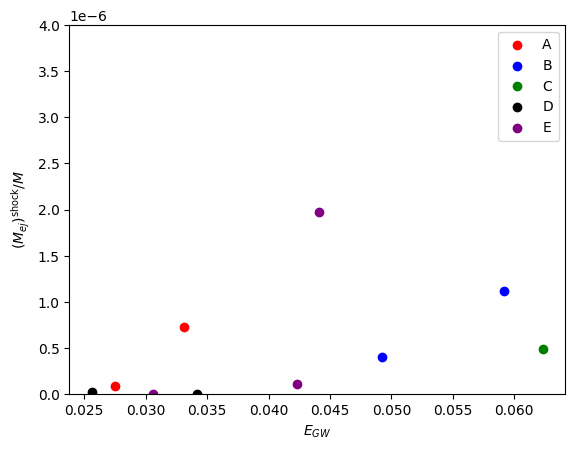

In [57]:
plotted = {'A': False,
           'B': False,
           'C': False,
           'D': False,
           'E': False,}

for model,shk_ej in avg_ej_shk_1p4.items():
    if not plotted[model]:
        plt.scatter(e_gw_rvss[(model,"1p4M")],shk_ej,color=RVSS_List[model][1],label=model)
        plotted[model] = True
    else:
        plt.scatter(e_gw_rvss[(model,"1p4M")],shk_ej,color=RVSS_List[model][1])


for model,shk_ej in avg_ej_shk_1p35.items():
    if not plotted[model]:
        plt.scatter(e_gw_rvss[(model,"1p35M")],shk_ej,color=RVSS_List[model][1],label=model)
        plotted[model] = True
    else:
        plt.scatter(e_gw_rvss[(model,"1p35M")],shk_ej,color=RVSS_List[model][1])



for model,shk_ej in avg_ej_shk_1p3.items():
    if not plotted[model]:
        plt.scatter(e_gw_rvss[(model,"1p3M")],shk_ej,color=RVSS_List[model][1],label=model)
        plotted[model] = True
    else:
        plt.scatter(e_gw_rvss[(model,"1p3M")],shk_ej,color=RVSS_List[model][1])
plt.xlabel(r'$E_{GW}$')
plt.ylabel(r'$(M_{ej})^{\text{shock}}/M$')
plt.ylim([0,0.4*10**(-5)])
plt.legend()